# Rimozione del rumore da un segnale rumoroso di un sensore di processo con PROC LOESS

## Riepilogo esecutivo

Un sensore di temperatura della camera di un forno su una linea di produzione viene campionato una volta al secondo durante l'avviamento, quindi ogni lettura mescola un transitorio termico non lineare lento (una rampa di riscaldamento veloce, un superamento di assestamento, poi un ritorno verso il setpoint di 300 °C) con un rumore di misura sostanziale. Questo notebook usa **PROC LOESS** per recuperare il segnale sottostante in modo non parametrico. Sul registro di 100 campioni, AICC ha selezionato un parametro di smoothing di 0,08 (8 parametri equivalenti); la curva risultante segue da vicino il segnale latente, lasciando residui con una deviazione standard di 3,10 °C — sostanzialmente i 4 °C di rumore che abbiamo iniettato, meno la varianza spiegata dal fit. Rispetto alla verità nota, la stima LOESS riduce l'errore quadratico medio da 14,77 (grezzo) a 6,63, e un passo SCORE ricampiona il segnale ripulito su una griglia di monitoraggio uniforme per il controllo statistico di processo a valle.

## Origine dei dati

| Dataset | Righe | Variabili | Descrizione |
|---------|------|-----------|-------------|
| `sensor` | 100 | `t` (secondi trascorsi, 0-99), `temp` (temperatura osservata della camera, °C), `truth` (segnale latente senza rumore, solo per validazione) | Registro sintetico di un sensore di forno, un campione al secondo. Il segnale latente è una rampa di riscaldamento veloce verso un setpoint di 300 °C con un superamento smorzato che raggiunge il picco vicino a t = 28 (~295 °C), scende, e si assesta di nuovo verso il setpoint; la `temp` osservata aggiunge rumore di misura gaussiano (ds ~4 °C). |
| `grid` | 60 | `t` (griglia di monitoraggio uniforme 0-99) | Griglia temporale regolare usata dall'istruzione SCORE per emettere un segnale ripulito equispaziato per grafici SPC. |

In una linea di produzione, un sensore della camera di un forno registra la temperatura una volta al secondo durante l'avviamento. La lettura che registriamo è lo **stato termico reale più rumore di misura**. Lo stato reale non segue una formula parametrica pulita — sale durante il riscaldamento, supera il setpoint, poi si assesta — quindi un fit lineare o polinomiale globale sarebbe un modello scadente.

La **regressione locale (LOESS)** è lo strumento giusto: adatta polinomi di basso grado a intorni locali scorrevoli, recuperando un segnale liscio arbitrario senza specificarne la forma funzionale. Qui:

1. Simuliamo un registro realistico di un sensore rumoroso di 100 campioni.
2. Lasciamo che `PROC LOESS` scelga da sé la larghezza di banda dello smoothing con il criterio AICC.
3. Attacchiamo una banda di confidenza al 95% al segnale adattato.
4. Valutiamo il modello su una griglia regolare per l'SPC a valle.
5. Quantifichiamo quanto rumore abbiamo rimosso.

## Passo 1 — Simulare il registro del sensore

Generiamo 100 campioni su 0-99 secondi. Il segnale latente `truth` è una rampa di riscaldamento veloce verso un setpoint di 300 °C con un superamento smorzato — una forma che nessuna retta o singolo polinomio cattura bene: sale ripidamente, supera il picco sopra il setpoint vicino a t = 28, scende, poi si assesta di nuovo. La `temp` osservata aggiunge rumore di misura gaussiano. `call streaminit` fissa il seme così l'esecuzione è riproducibile.

In [1]:
DATI sensor;
    CHIAMARE streaminit(70421);
    setpoint = 300;
    FARE t = 0 FINO_A 99;
        /* Segnale latente: rampa di riscaldamento veloce + superamento smorzato */
        ramp      = setpoint * (1 - EXP(-t / 10));
        overshoot = 40 * EXP(-t / 35) * sin(t / 11);
        truth     = ramp + overshoot;
        /* Lettura osservata = truth + rumore di misura (ds ~4 C) */
        temp = truth + rand('NORMAL', 0, 4);
        USCITA;
    FINE;
    MANTENERE t temp truth;
ESEGUIRE;

PROCEDURA STAMPARE DATI=sensor(obs=8) noobs;
    TITOLO "Primi 8 campioni del sensore";
ESEGUIRE;

                                              Primi 8 campioni del sensore                                              

t            temp           truth
0    0.1684867131               0
1   28.1933107495   32.0778466448
2   61.6123615699   61.2117857105
3   85.5053781561    87.643846097
4  110.5560474248  111.5945193774
5  136.6368358359  133.2650493509
6  144.2434193147  152.8394750856
7  177.8286488692  170.4864506364

... 92 more observations (showing 8 of 100)




NOTE: DATA sensor


NOTE: Wrote sensor (100 rows, 3 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: PROC PRINT data=sensor

NOTE: PROC PRINT completed: 8 observations printed, 3 variables


## Passo 2 — Ispezionare il segnale grezzo

Un rapido grafico a dispersione mostra il problema: la deriva sottostante è ovvia all'occhio ma sepolta sotto il rumore campione per campione. Ci serve una stima della curva liscia, non i punti irregolari.

                                              Primi 8 campioni del sensore                                              




NOTE: ODS Graphics is ON (width=640px, height=480px, format=SVG).
NOTE: PROC SGPLOT data=sensor

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot.svg
NOTE: ODS Graphics is OFF.


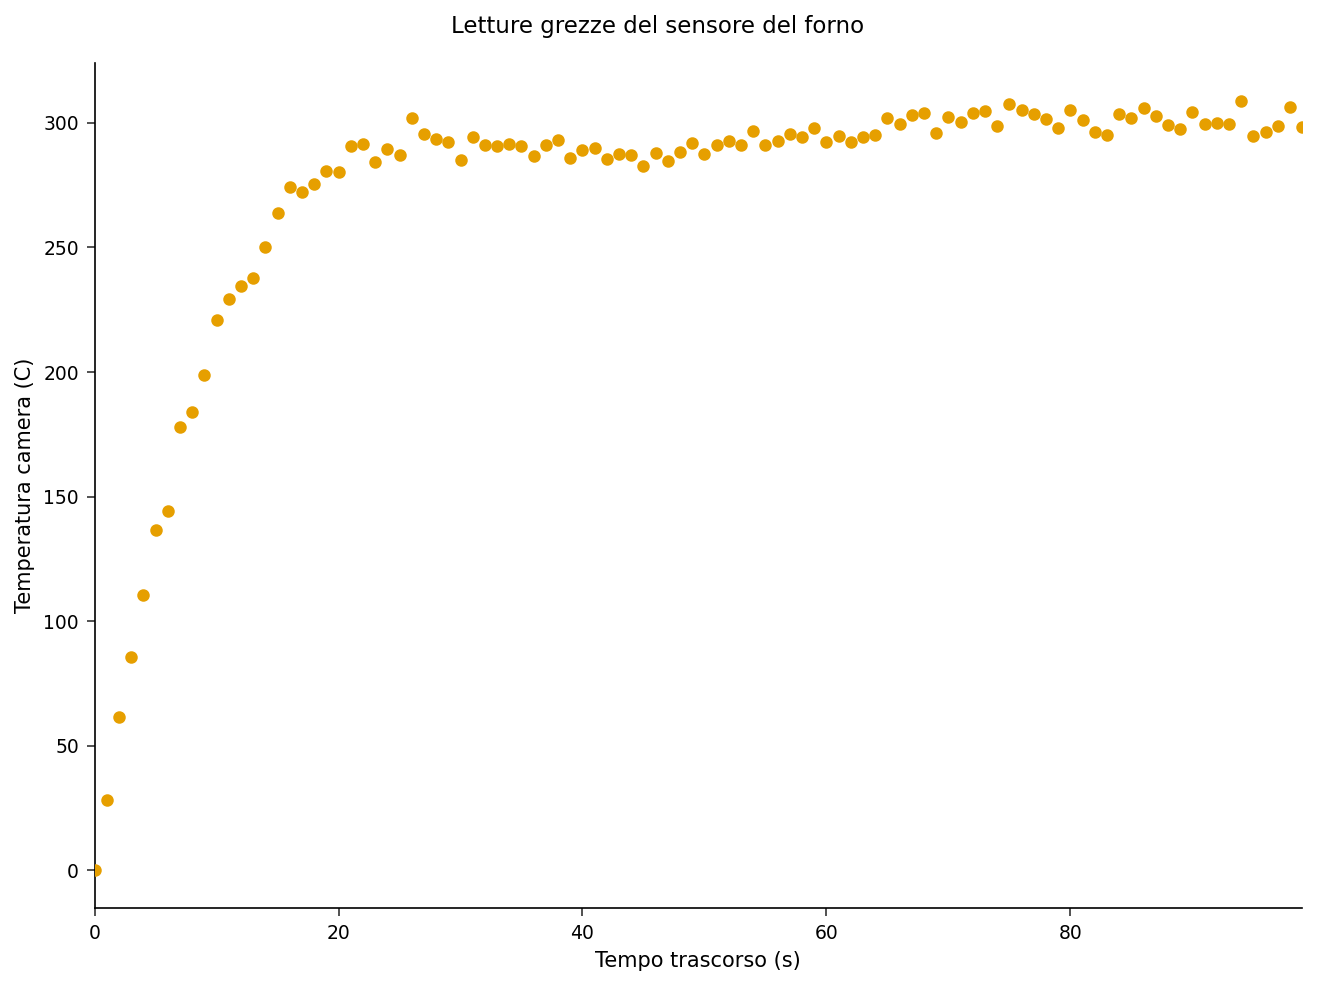

In [2]:
ODS GRAPHICS ON;

PROCEDURA SGPLOT DATI=sensor;
    SCATTER x=t y=temp / MARKERATTRS=(SYMBOL=circlefilled size=5);
    XAXIS ETICHETTA='Tempo trascorso (s)';
    YAXIS ETICHETTA='Temperatura camera (C)';
    TITOLO 'Letture grezze del sensore del forno';
ESEGUIRE;

ODS GRAPHICS OFF;

## Passo 3 — Adattare LOESS con selezione automatica della larghezza di banda

Il parametro di smoothing controlla quanto è ampio ogni intorno locale: troppo piccolo esegue overfitting del rumore, troppo grande cancella il superamento. Invece di indovinare, lasciamo che LOESS lo scelga minimizzando il **criterio di informazione di Akaike corretto** con `select=AICC`. Usiamo polinomi quadratici locali (`degree=2`) così la curva può seguire la curvatura del riscaldamento e del superamento, e richiediamo una banda di confidenza al 95% con `clm` e `alpha=0.05`.

`ODS OUTPUT` cattura due tabelle come dataset: `OutputStatistics` (valori adattati e residui per punto) e `FitSummary` (la larghezza di banda selezionata e le diagnostiche del fit). L'istruzione `OUTPUT` scrive un dataset `fitted` con la previsione, il residuo e i limiti di confidenza al 95% per ogni osservazione — la materia prima per i grafici che seguono.

In [3]:
PROCEDURA loess DATI=sensor;
    ODS OUTPUT OutputStatistics=loess_fit
               FitSummary=fit_summary;
    MODELLO temp = t / DEGREE=2 select=AICC CLM ALPHA=0.05 details;
    USCITA out=fitted predicted=temp_hat residual=resid
           lclm=LOWER uclm=UPPER;
ESEGUIRE;

                                              Primi 8 campioni del sensore                                              


                                                  The LOESS Procedure

Dependent Variable: temp
Number of Observations: 100
Smoothing Parameter: 0.0800
Degree of Local Polynomials: 2

Fit Summary
-----------
Residual Sum of Squares: 950.859192
Equivalent Number of Parameters: 8.00
AICC: 529.0073
GCV: 11.234159

Output Statistics
Obs        Smoothed     Residual       Fitted
---        --------     --------       ------
1           -0.3394       0.5079      -0.3394
2           30.1685      -1.9751      30.1685
3           58.9327       2.6796      58.9327
4           86.1852      -0.6798      86.1852
5          111.5155      -0.9595     111.5155
6          135.0464       1.5904     135.0464
7          155.9315     -11.6881     155.9315
8          168.9956       8.8330     168.9956
9          184.5066      -0.4446     184.5066
10         202.2409      -3.5166     202


NOTE: PROC LOESS data=sensor

NOTE: ODS OUTPUT: OutputStatistics -> loess_fit
NOTE: ODS OUTPUT: FitSummary -> fit_summary
NOTE: Using Python wrapper for LOESS estimation
NOTE: Output dataset fitted has 100 observations
NOTE: ODS OUTPUT: OutputStatistics written to 'loess_fit'.
NOTE: ODS OUTPUT: FitSummary written to 'fit_summary'.


## Passo 4 — Rivedere il modello selezionato

Il Fit Summary registra il parametro di smoothing ottimale AICC e la traccia della matrice di previsione (i gradi di libertà effettivi — una misura della complessità del modello). Un parametro di smoothing più piccolo e un DF più grande significano un fit più mosso; AICC bilancia automaticamente fit e complessità.

In [4]:
PROCEDURA STAMPARE DATI=fit_summary noobs label;
    TITOLO "Riepilogo del fit LOESS (larghezza di banda selezionata da AICC)";
ESEGUIRE;

                            Riepilogo del fit LOESS (larghezza di banda selezionata da AICC)                            

SMOOTHINGPARAMETER                           LABEL1         NVALUE1
              0.08  Residual Sum of Squares          950.8591917253
              0.08  Equivalent Number of Parameters               8
              0.08  Delta1                                        8
              0.08  Delta2                                      7.6
              0.08  Lookup Degrees of Freedom                    92




NOTE: PROC PRINT data=fit_summary

NOTE: PROC PRINT completed: 5 observations printed, 3 variables


## Passo 5 — Sovrapporre il fit e la banda di confidenza alla verità nota

Poiché questi sono dati simulati, abbiamo conservato la colonna `truth` senza rumore. Tracciare la stima LOESS e la sua banda al 95% insieme a `truth` mostra quanto fedelmente lo smoother abbia recuperato il segnale latente che non ha mai visto direttamente.

                            Riepilogo del fit LOESS (larghezza di banda selezionata da AICC)                            




NOTE: PROC SORT data=fitted

NOTE: Unlicensed mode - input limited to 100 observations.
NOTE: Read 100 rows from fitted.
NOTE: Wrote fitted (100 rows, 7 columns).
NOTE: PROC SORT statement used.
NOTE: ODS Graphics is ON (width=640px, height=480px, format=SVG).
NOTE: PROC SGPLOT data=fitted

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot1.svg
NOTE: ODS Graphics is OFF.


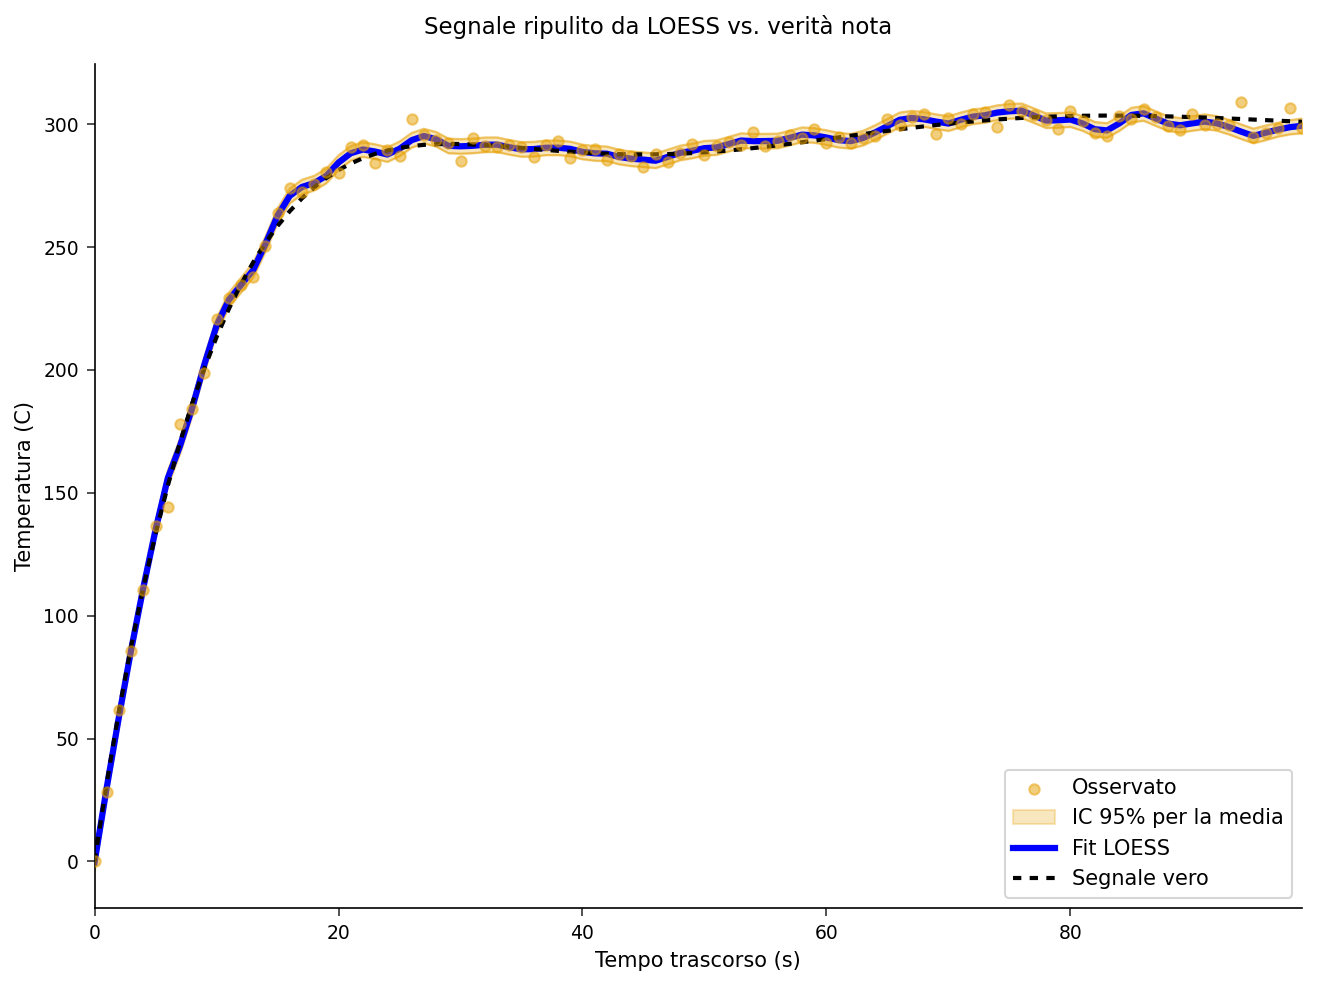

In [5]:
PROCEDURA ORDINARE DATI=fitted; PER t; ESEGUIRE;

ODS GRAPHICS ON;

PROCEDURA SGPLOT DATI=fitted;
    SCATTER x=t y=temp / MARKERATTRS=(SYMBOL=circlefilled size=5)
            TRANSPARENCY=0.5 legendlabel='Osservato';
    BAND x=t LOWER=LOWER UPPER=UPPER / TRANSPARENCY=0.5
         legendlabel='IC 95% per la media';
    SERIES x=t y=temp_hat / LINEATTRS=(thickness=3 color=blue)
           legendlabel='Fit LOESS';
    SERIES x=t y=truth / LINEATTRS=(thickness=2 pattern=shortdash color=black)
           legendlabel='Segnale vero';
    XAXIS ETICHETTA='Tempo trascorso (s)';
    YAXIS ETICHETTA='Temperatura (C)';
    TITOLO 'Segnale ripulito da LOESS vs. verità nota';
ESEGUIRE;

ODS GRAPHICS OFF;

## Passo 6 — Diagnostica dei residui

I residui (osservato meno adattato) dovrebbero apparire come rumore privo di struttura centrato su zero. Qualsiasi tendenza residua segnalerebbe un sotto-smoothing o una caratteristica mancata. Tracciamo i residui rispetto al tempo e ne riassumiamo la dispersione — la deviazione standard dei residui risulta 3,10 °C, leggermente sotto i 4 °C di rumore iniettato perché il fit locale ne assorbe una piccola quota.

                            Riepilogo del fit LOESS (larghezza di banda selezionata da AICC)                            

                                  Riepilogo dei residui (rumore di misura recuperato)                                   

                                                  The MEANS Procedure

 Variable  Label               N        Mean     Std Dev     Minimum     Maximum
 -------------------------------------------------------------------------------
 RESID     Residuo (C)       100       0.139       3.096     -11.688      11.909
 -------------------------------------------------------------------------------




NOTE: ODS Graphics is ON (width=640px, height=480px, format=SVG).
NOTE: PROC SGPLOT data=fitted

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot2.svg
NOTE: ODS Graphics is OFF.
NOTE: PROC MEANS
NOTE: PROC MEANS statement used.


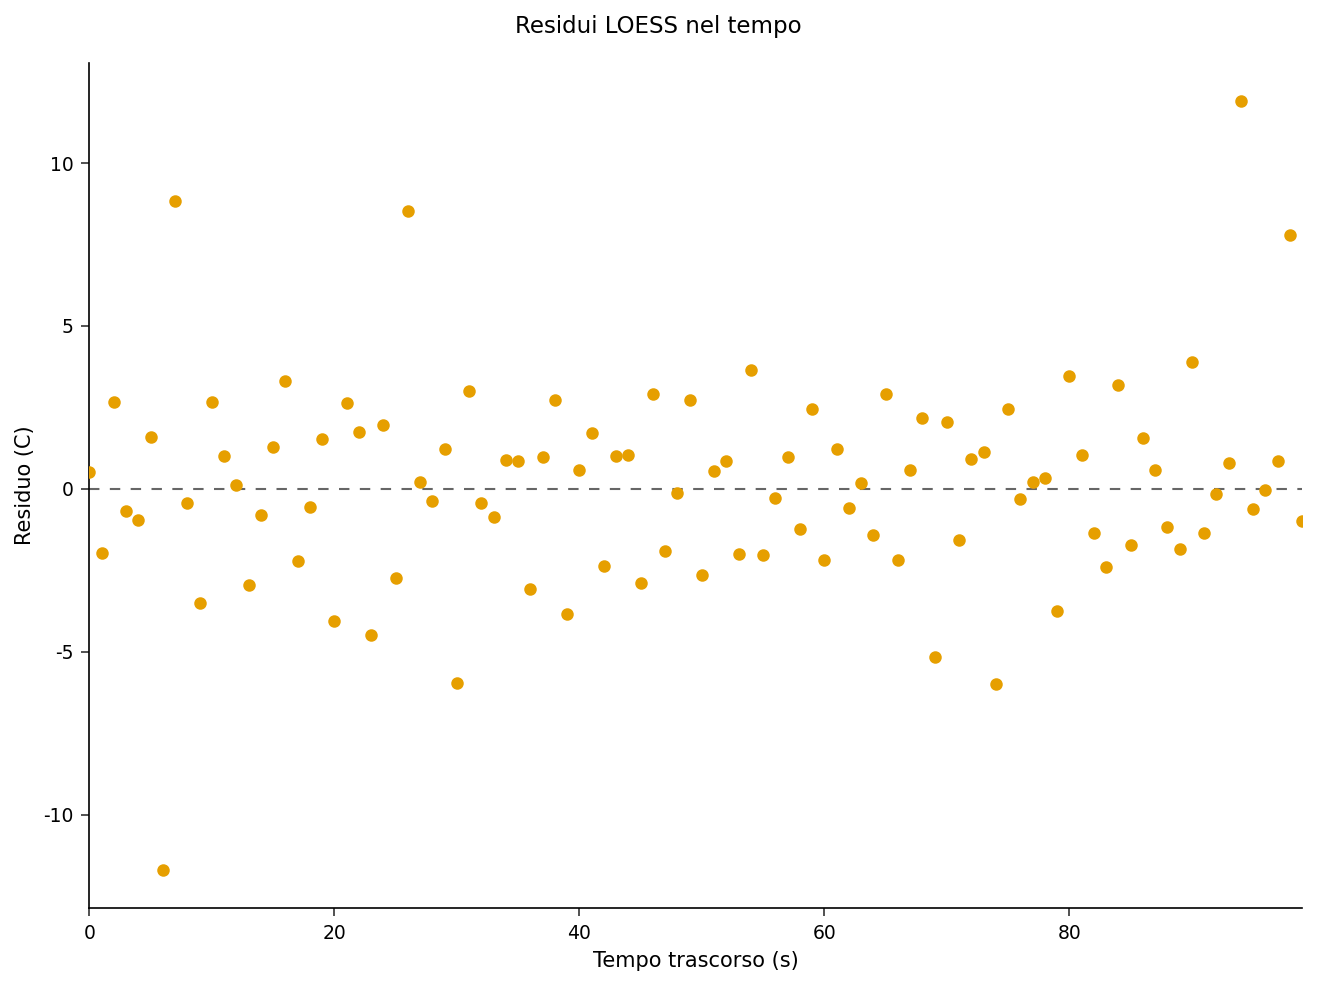

In [6]:
ODS GRAPHICS ON;

PROCEDURA SGPLOT DATI=fitted;
    REFLINE 0 / AXIS=y LINEATTRS=(pattern=shortdash);
    SCATTER x=t y=resid / MARKERATTRS=(SYMBOL=circlefilled size=5);
    XAXIS ETICHETTA='Tempo trascorso (s)';
    YAXIS ETICHETTA='Residuo (C)';
    TITOLO 'Residui LOESS nel tempo';
ESEGUIRE;

ODS GRAPHICS OFF;

PROCEDURA MEDIE DATI=fitted n mean std MIN MAX maxdec=3;
    VARIABILE resid;
    ETICHETTA resid="Residuo (C)";
    TITOLO "Riepilogo dei residui (rumore di misura recuperato)";
ESEGUIRE;

## Passo 7 — Valutare una griglia di monitoraggio regolare per l'SPC

I timestamp del sensore non devono essere necessariamente equispaziati, ma un grafico di controllo vuole il segnale su una cadenza fissa. Costruiamo una griglia temporale uniforme di 60 punti e applichiamo il modello LOESS adattato con l'istruzione `SCORE`, richiedendo i limiti di confidenza. I valori valutati sono un segnale pulito ed equispaziato pronto per alimentare una routine SPC.

In [7]:
DATI grid;
    FARE t = 0 FINO_A 99 PER 99/59;
        USCITA;
    FINE;
ESEGUIRE;

PROCEDURA loess DATI=sensor;
    MODELLO temp = t / DEGREE=2 select=AICC CLM ALPHA=0.05;
    SCORE DATI=grid CLM print;
    TITOLO "LOESS valutato su una griglia di monitoraggio uniforme";
ESEGUIRE;

                                  Riepilogo dei residui (rumore di misura recuperato)                                   


                                                  The LOESS Procedure

Dependent Variable: temp
Number of Observations: 100
Smoothing Parameter: 0.0800
Degree of Local Polynomials: 2

Fit Summary
-----------
Residual Sum of Squares: 950.859192
Equivalent Number of Parameters: 8.00
AICC: 529.0073
GCV: 11.234159

Output Statistics
Obs        Smoothed     Residual       Fitted
---        --------     --------       ------
1           -0.3394       0.5079      -0.3394
2           30.1685      -1.9751      30.1685
3           58.9327       2.6796      58.9327
4           86.1852      -0.6798      86.1852
5          111.5155      -0.9595     111.5155
6          135.0464       1.5904     135.0464
7          155.9315     -11.6881     155.9315
8          168.9956       8.8330     168.9956
9          184.5066      -0.4446     184.5066
10         202.2409      -3.5166     202


NOTE: DATA grid


NOTE: Wrote grid (60 rows, 1 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: PROC LOESS data=sensor

NOTE: Using Python wrapper for LOESS estimation
NOTE: ODS OUTPUT: OutputStatistics written to 'loess_fit'.
NOTE: ODS OUTPUT: FitSummary written to 'fit_summary'.


## Passo 8 — Quantificare la rimozione del rumore

Infine confrontiamo il segnale grezzo e la stima LOESS rispetto alla verità nota. L'errore quadratico medio del segnale ripulito dovrebbe essere molto più piccolo di quello delle letture grezze, confermando che LOESS ha eliminato il rumore di misura preservando la rampa di riscaldamento e il superamento.

In [8]:
DATI accuracy;
    IMPOSTARE fitted;
    raw_sq_err   = (temp     - truth)**2;
    loess_sq_err = (temp_hat - truth)**2;
ESEGUIRE;

PROCEDURA MEDIE DATI=accuracy mean maxdec=3;
    VARIABILE raw_sq_err loess_sq_err;
    ETICHETTA raw_sq_err   = "MSE delle letture grezze rispetto alla verità"
          loess_sq_err = "MSE del fit LOESS rispetto alla verità";
    TITOLO "Prestazioni di rimozione del rumore: grezzo vs. LOESS";
ESEGUIRE;

                                 Prestazioni di rimozione del rumore: grezzo vs. LOESS                                  

                                                  The MEANS Procedure

 Variable      Label                                                    Mean
 ---------------------------------------------------------------------------
 raw_sq_err    MSE delle letture grezze rispetto alla verità          14.774
 loess_sq_err  MSE del fit LOESS rispetto alla verità                  6.629
 ---------------------------------------------------------------------------




NOTE: DATA accuracy


NOTE: Read 100 rows from fitted.
NOTE: Wrote accuracy (100 rows, 9 columns).
NOTE: DATA elapsed:
  wall  0.01 seconds
  cpu   0.01 seconds
NOTE: PROC MEANS
NOTE: PROC MEANS statement used.


## Interpretazione dei risultati

- **Larghezza di banda automatica.** `select=AICC` ha scelto un parametro di smoothing di **0,08** senza regolazione manuale, implicando circa **8 parametri equivalenti** — abbastanza flessibilità locale per seguire il riscaldamento, il superamento e la discesa, pur smussando il rumore.
- **Recupero fedele.** La curva adattata segue da vicino il segnale latente `truth` lungo la rampa, il picco del superamento vicino a t = 28, e la coda di assestamento, dimostrando che LOESS ha recuperato un segnale non lineare arbitrario senza alcuna assunzione parametrica.
- **Residui puliti.** I residui si disperdono attorno allo zero con una deviazione standard di **3,10 °C** (media 0,14, intervallo da −11,7 a 11,9) e non mostrano alcuna tendenza temporale residua — prova che il modello non è né sovra- né sotto-smussato.
- **Rimozione del rumore misurabile.** Rispetto alla verità nota, la stima LOESS riduce l'errore quadratico medio da **14,77** (letture grezze) a **6,63** — una riduzione del 55%, il beneficio principale per il monitoraggio di processo.
- **Output pronto per SPC.** Il passo SCORE ha fornito il segnale ripulito su una griglia uniforme di 60 punti con limiti di confidenza, esattamente la forma che un grafico di controllo a valle consuma.

**Conclusione:** Quando un sensore di processo produce un segnale liscio ma rumoroso di forma sconosciuta, PROC LOESS è un modo a basse assunzioni e auto-regolante per estrarre la tendenza sottostante, allegare limiti di incertezza e ricampionare su una griglia di monitoraggio — tutto senza impegnarsi in un modello parametrico che la fisica potrebbe non giustificare.